In [102]:
import pandas as pd

# load dataset
df=pd.read_csv(r'/kaggle/input/amazon-sales-data/Amazon Sale Report.csv')

/tmp/ipykernel_38/408111916.py:4: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r'/kaggle/input/amazon-sales-data/Amazon Sale Report.csv')


In [103]:
df.head() # Display the first 5 lines of the dataset

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [105]:
df_sizes = {'start': df.shape}

* Check the dimension of the data

In [109]:
print(f"Raw data contains {df_sizes['start'][0]} records and {df_sizes['start'][1]} columns.")

Raw data contains 128975 records and 24 columns.


* Standardize the column names
  

In [110]:
df.columns


Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

* rename columns names

In [116]:
df = df.rename(columns={'Order ID': 'Order_ID', 'Sales Channel ': 'Sales_channel',
        'ship-service-level': 'ship_service_level', 'ship-city': 'ship_city', 
        'ship-state': 'ship_state', 'ship-postal-code': 'ship_postal_code', 'ship-country': 'ship_country', 
        'promotion-ids': 'promotion_ids','Courier Status': 'Courier_Status', 'currency': 'Currency', 
        'fulfilled-by':'fulfilled_by'})

* Check columns data type

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128975 entries, 0 to 128974
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order_ID            128975 non-null  object 
 1   Date                128975 non-null  object 
 2   Status              128975 non-null  object 
 3   Fulfilment          128975 non-null  object 
 4   Sales_channel       128975 non-null  object 
 5   ship_service_level  128975 non-null  object 
 6   Style               128975 non-null  object 
 7   SKU                 128975 non-null  object 
 8   Category            128975 non-null  object 
 9   Size                128975 non-null  object 
 10  ASIN                128975 non-null  object 
 11  Courier_Status      122103 non-null  object 
 12  Qty                 128975 non-null  int64  
 13  Currency            121180 non-null  object 
 14  Amount              121180 non-null  float64
 15  ship_city           128942 non-null  ob

* Set the column 'index' as the index of the dataframe. With this operation the number of columns becomes 22.

In [114]:
df.set_index('index', inplace = True)

KeyError: "None of ['index'] are in the columns"

* Create a separate dataframe containing the informations about missing and unique values for each column, to better see the correlations.

In [63]:
def missing_evaluation(dataframe):
    '''
    missing_evaluation(dataframe)
    
    Returns a dataframe containing the informations about missing and unique values 
    for each column on a dataframe passed as a parameter

    Parameters: 
    dataframe: dataframe to analyze
    '''
    
    # Column 'qt_missing': Number of NaN values
    df_missing_stats = pd.DataFrame(data=dataframe.isna().sum(), index=dataframe.columns, columns=['qt_missing'])
    # Column 'nr_unique_values': Number of unique values
    df_missing_stats['qt_unique_values'] = pd.DataFrame(data=dataframe.nunique(), index=dataframe.columns)
    # Column 'unique_values': unique values of the attributes
    df_missing_stats['unique_values'] = pd.DataFrame(data=dataframe.apply(pd.unique), index=dataframe.columns)
    # Column 'perc_missing': percentage of missing values
    df_missing_stats['perc_missing'] = pd.DataFrame(data=dataframe.isnull().mean())
    return df_missing_stats

In [64]:
df_missing_stats = missing_evaluation(df)
df_missing_stats

,qt_missing,qt_unique_values,unique_values,perc_missing
Order_ID,0,120378,"[405-8078784-5731545, 171-9198151-1101146, 404...",0.000000
Date,0,91,"[04-30-22, 04-29-22, 04-28-22, 04-27-22, 04-26...",0.000000
Status,0,13,"[Cancelled, Shipped - Delivered to Buyer, Ship...",0.000000
Fulfilment,0,2,"[Merchant, Amazon]",0.000000
Sales_channel,0,2,"[Amazon.in, Non-Amazon]",0.000000
ship_service_level,0,2,"[Standard, Expedited]",0.000000
Style,0,1377,"[SET389, JNE3781, JNE3371, J0341, JNE3671, SET...",0.000000
SKU,0,7195,"[SET389-KR-NP-S, JNE3781-KR-XXXL, JNE3371-KR-X...",0.000000
Category,0,9,"[Set, kurta, Western Dress, Top, Ethnic Dress,...",0.000000
Size,0,11,"[S, 3XL, XL, L, XXL, XS, 6XL, M, 4XL, 5XL, Free]",0.000000


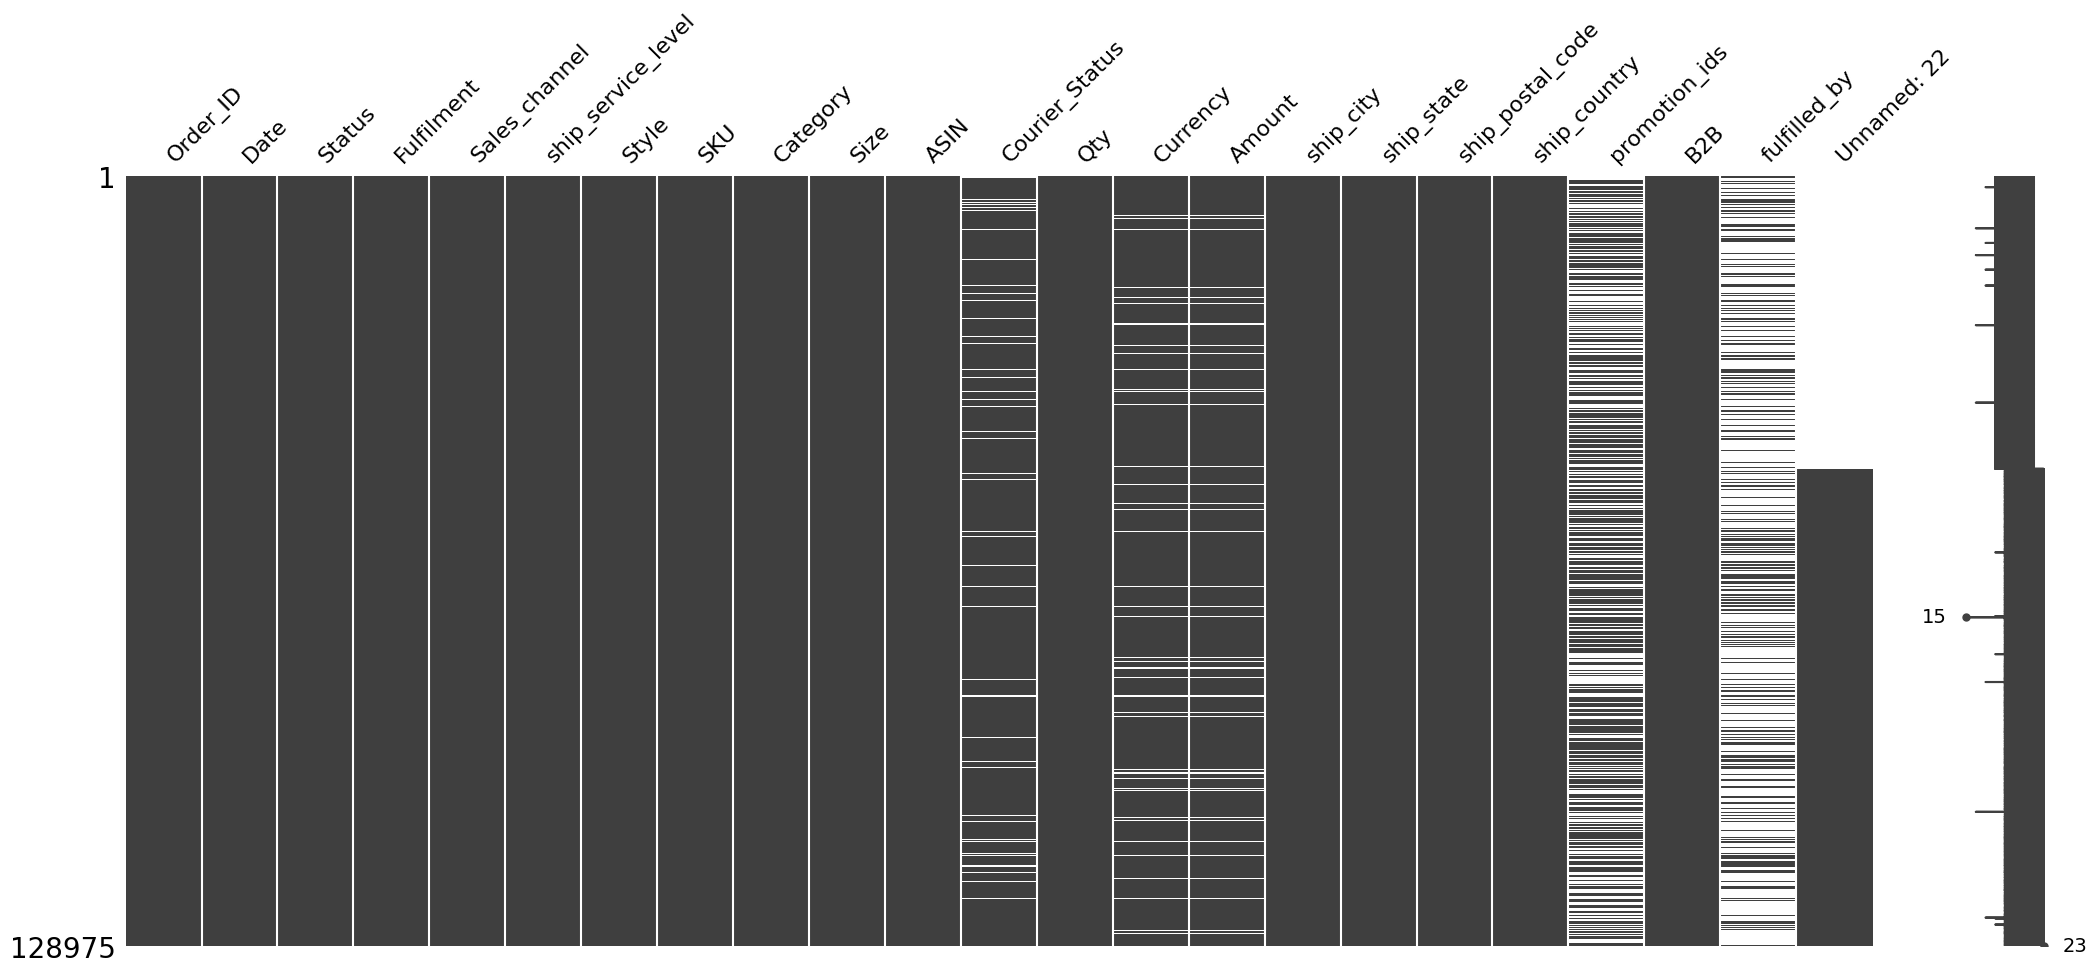

In [65]:
# Visualize the distribution of missing values with missingno matrix
import missingno as msno

msno.matrix(df);

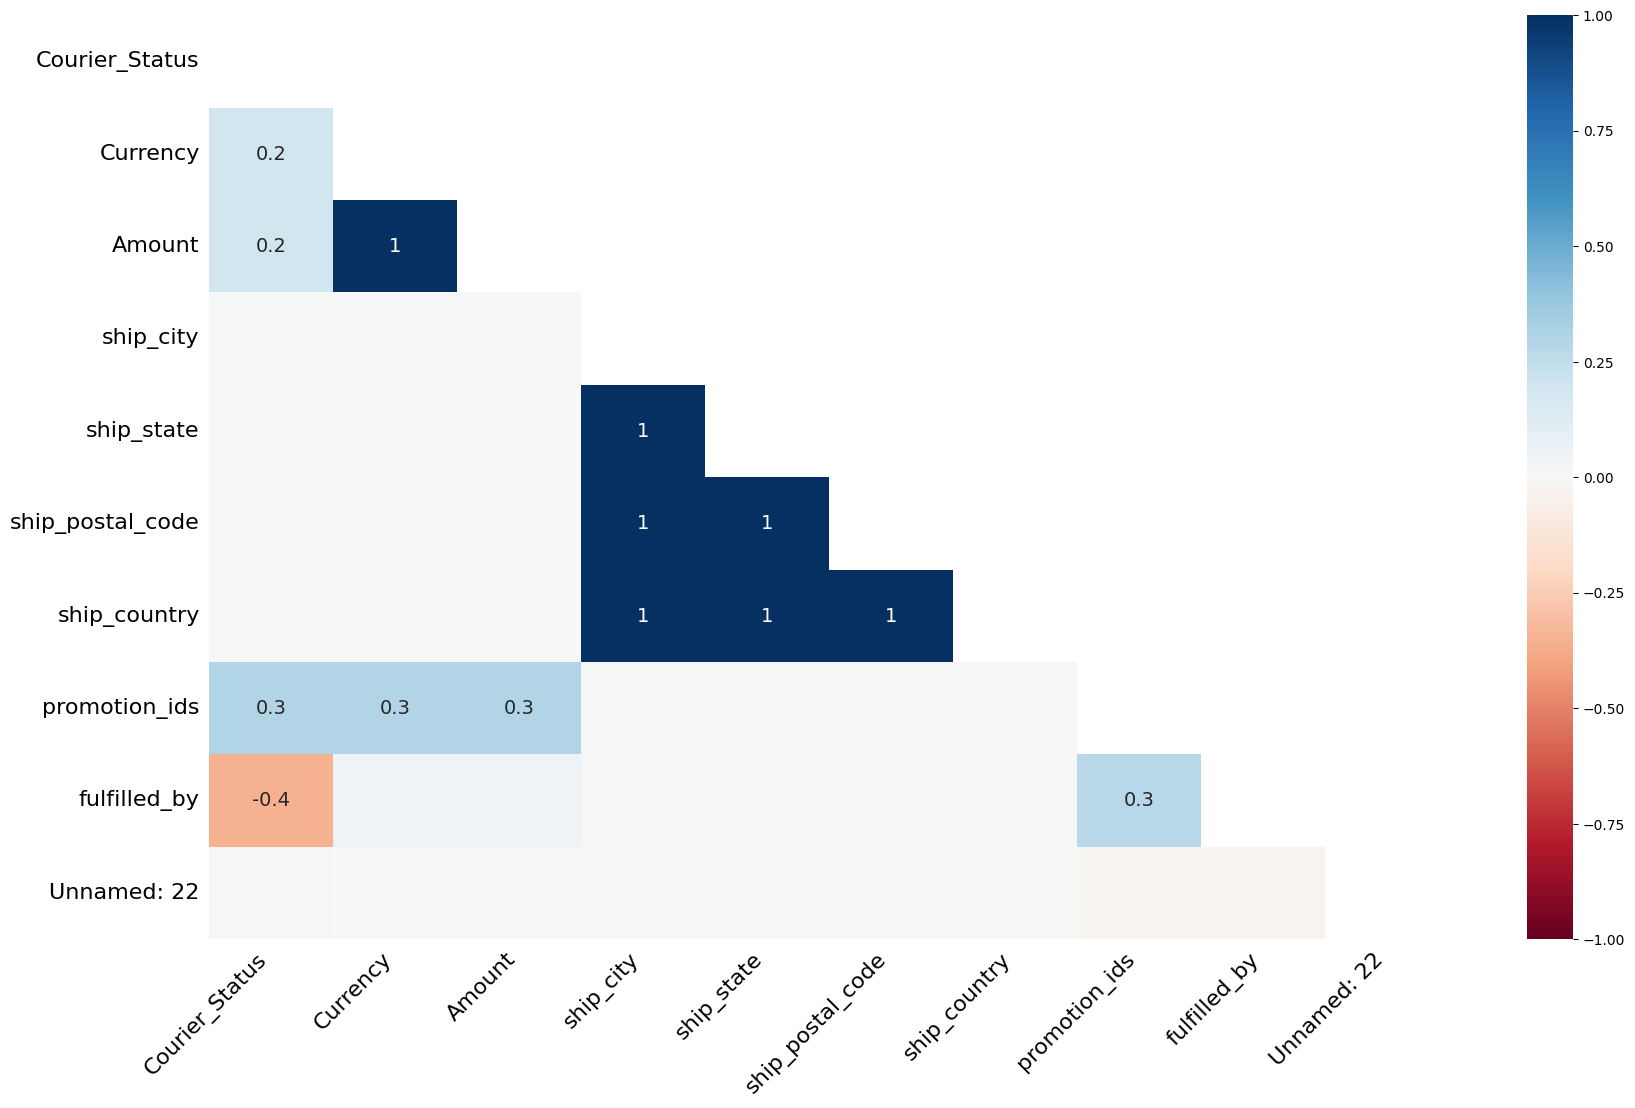

In [66]:
import seaborn as sns
# Use the heatmap to identify correlations of the nullity between each of the different columns.
msno.heatmap(df);

In [67]:
# Replace NaN values in column 'Courier_Status' with the value 'Unknown'
df['Courier_Status'].fillna('Unknown', inplace = True)
#df['Courier_Status'].isna().sum()

/tmp/ipykernel_38/263707862.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Courier_Status'].fillna('Unknown', inplace = True)


* Check nullity correlation on **Amount** and **Currency** columns
* Fill missing values in **Amount** with zero
* Fill missing values in **Currency** with 'INR'

In [68]:
set_idx_amount_null = set(df[df['Amount'].isnull()].index)

In [69]:
set2_idx_currency_null = set(df[df['Currency'].isnull()].index)

In [70]:
print(f"Question: Columns 'Amount' and 'Currency' have 1 to 1 nullity correlation?\nAnswer: {set_idx_amount_null == set2_idx_currency_null}") 

Question: Columns 'Amount' and 'Currency' have 1 to 1 nullity correlation?
Answer: True


In [71]:
df['Amount'].fillna(0, inplace = True)

/tmp/ipykernel_38/4267837074.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Amount'].fillna(0, inplace = True)


In [72]:
df['Currency'].fillna('INR', inplace = True)

/tmp/ipykernel_38/2678195068.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Currency'].fillna('INR', inplace = True)


* **promotion_ids**: missing values filled with 'No Promo'

In [73]:
# Replace NaN values in column 'promotion_ids' with the value 'Unknown'
df['promotion_ids'].fillna('No Promo', inplace = True)

/tmp/ipykernel_38/2107257680.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['promotion_ids'].fillna('No Promo', inplace = True)


* **ship_city** and **ship_state**: missing values filled with 'Unknown'
* **ship_postal_code**: missing values filled with zero
* **ship_country**: missing values filled with 'Unknown'

In [74]:
df['ship_city'].fillna('Unknown', inplace = True)
df['ship_state'].fillna('Unknown', inplace = True)
df['ship_postal_code'].fillna(0, inplace = True)
df['ship_country'].fillna('Unknown', inplace = True)

/tmp/ipykernel_38/3931634243.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ship_city'].fillna('Unknown', inplace = True)
/tmp/ipykernel_38/3931634243.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

* **fulfilled_by**: missing values filled with 'FBA' (Fulfilled by Amazon).

In [75]:
df['fulfilled_by'].fillna('FBA', inplace = True)

/tmp/ipykernel_38/646876717.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['fulfilled_by'].fillna('FBA', inplace = True)


* **Unnamed: 22** will be deleted because it isn't relevant

In [76]:
df.drop(columns = ['Unnamed: 22'], inplace = True)

### Check that none of the missing values are left

In [77]:
df.isna().sum().sum()

0

In [78]:
df_missing_stats = missing_evaluation(df)
df_missing_stats

,qt_missing,qt_unique_values,unique_values,perc_missing
Order_ID,0,120378,"[405-8078784-5731545, 171-9198151-1101146, 404...",0.0
Date,0,91,"[04-30-22, 04-29-22, 04-28-22, 04-27-22, 04-26...",0.0
Status,0,13,"[Cancelled, Shipped - Delivered to Buyer, Ship...",0.0
Fulfilment,0,2,"[Merchant, Amazon]",0.0
Sales_channel,0,2,"[Amazon.in, Non-Amazon]",0.0
ship_service_level,0,2,"[Standard, Expedited]",0.0
Style,0,1377,"[SET389, JNE3781, JNE3371, J0341, JNE3671, SET...",0.0
SKU,0,7195,"[SET389-KR-NP-S, JNE3781-KR-XXXL, JNE3371-KR-X...",0.0
Category,0,9,"[Set, kurta, Western Dress, Top, Ethnic Dress,...",0.0
Size,0,11,"[S, 3XL, XL, L, XXL, XS, 6XL, M, 4XL, 5XL, Free]",0.0


##  Uniform the values in each column [&#129081;](#Top)<a name="UniformValues_df1"></a>


* **Order_ID**: it's proper that it's a string, remove extra white spaces from the beginning and end, and set the characters in UPPER case.

In [79]:
df['Order_ID'] = df['Order_ID'].str.strip()

In [80]:
df['Order_ID'] = df['Order_ID'].str.upper()

* **Date**: it's in string format, set it to to dtype datetime. 

In [81]:
# Set column 'Date' to data type datetime
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_38/2574689105.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [82]:
df['Status'] = df['Status'].str.strip()

In [83]:
# Check column 'Status', result: it doesn't need intervention
for value in df.Status.sort_values().unique():
    print(f"'{value}'")

'Cancelled'
'Pending'
'Pending - Waiting for Pick Up'
'Shipped'
'Shipped - Damaged'
'Shipped - Delivered to Buyer'
'Shipped - Lost in Transit'
'Shipped - Out for Delivery'
'Shipped - Picked Up'
'Shipped - Rejected by Buyer'
'Shipped - Returned to Seller'
'Shipped - Returning to Seller'
'Shipping'


* **Style** and **SKU**: it's proper that they are strings, remove extra white spaces from the beginning and end, and set the characters in UPPER case.

In [84]:
df['Style'] = df['Style'].str.strip()
df['Style'] = df['Style'].str.upper()
df['SKU'] = df['SKU'].str.strip()
df['SKU'] = df['SKU'].str.upper()

* **Category**: it's proper that it's a string, remove extra white spaces from the beginning and end, and set the characters in UPPER case.

In [85]:
df['Category'] = df['Category'].str.strip()
df['Category'] = df['Category'].str.upper()

* **ASIN**: it's proper that it's a string, remove extra white spaces from the beginning and end, and set the characters in UPPER case.

In [86]:
df['ASIN'] = df['ASIN'].str.strip()
df['ASIN'] = df['ASIN'].str.upper()

* **Courier_Status**: contains 4 unique values (Shipped, Cancelled, Unshipped, Unknown), and are already written in the correct form.   
* **Qty**: is a integer number, with max value of 15 units. It doesn't nedd intervention. 
* **Currency**: contains 1 unique value (INR), and is already written in the correct form.  
* **Amount**: is a float number. With the measurements made so far it doesn't seem to need intervention.

* **ship_city** and **ship_state**: it’s proper that they are strings, remove extra white spaces from the beginning and end, and uniform all the characters to UPPER case. Then check the accuracy of geographic names. And normalize different istances of the same state and city.

In [87]:
df['ship_city'] = df['ship_city'].str.strip()
df['ship_city'] = df['ship_city'].str.upper()
df['ship_state'] = df['ship_state'].str.strip()
df['ship_state'] = df['ship_state'].str.upper()

In [88]:
df.loc[df['ship_state'].isin(['AR']),'ship_state'] = 'ARUNACHAL PRADESH'
df.loc[df['ship_state'].isin(['NEW DELHI']),'ship_state'] = 'DELHI'
df.loc[df['ship_state'].isin(['NL']),'ship_state'] = 'NAGALAND'
df.loc[df['ship_state'].isin(['ORISSA']),'ship_state'] = 'ODISHA'
df.loc[df['ship_state'].isin(['PONDICHERRY']),'ship_state'] = 'PUDUCHERRY'
df.loc[df['ship_state'].isin(['PUNJAB/MOHALI/ZIRAKPUR','PB']),'ship_state'] = 'PUNJAB'
df.loc[df['ship_state'].isin(['RAJSHTHAN','RAJSTHAN','RJ']),'ship_state'] = 'RAJASTHAN'

In [89]:
df['ship_city'] = df['ship_city'].replace(['PUDUCHERRY','PONDYCHERRY', 'PUDUCHERRY 605001', 'PUDUCHERRY 605003'],'PUDUCHERRY')

In [90]:
df['ship_city'] = df['ship_city'].replace(['NORTH DELHI', 'NORTH WEST DELHI','NEW DELHI (NORTH)'],'NEW DELHI (NORTH)')
df['ship_city'] = df['ship_city'].replace(['SOUTH  DELHI', 'SOUTH DELHI'],'NEW DELHI (SOUTH)')
df['ship_city'] = df['ship_city'].replace(['SOUTH EAST DELHI'],'NEW DELHI (SOUTH EAST)')
df['ship_city'] = df['ship_city'].replace(['SOUTH WEST DELHI','SOUTH-WEST DELHI'],'NEW DELHI (SOUTH WEST)')
df['ship_city'] = df['ship_city'].replace(['WEST DELHI'],'NEW DELHI (WEST)')
df['ship_city'] = df['ship_city'].replace(['CENTRAL DELHI','CITY'],'NEW DELHI (CENTRAL)')
df['ship_city'] = df['ship_city'].replace(['EAST DELHI'],'NEW DELHI (EAST)')

In [91]:
import re

pattern = r'^NEW DELHI(?!.*\()'
df['ship_city'] = df['ship_city'].apply(lambda x: "NEW DELHI" if re.match(pattern, x) else x)

In [92]:
df['ship_city'] = df['ship_city'].replace(['N.DELHI','NEW DELH','DELHI','DELHI -86','DELHI 110085','DELHI CANTT','DELHI-92.','DELHIQ', 'NEW-DELHI',
 'NEWDELHI'],'NEW DELHI')

In [93]:
pattern = r'^BANGALOR(?!.*\()'
df['ship_city'] = df['ship_city'].apply(lambda x: 'BANGALORE' if re.match(pattern, x) else x)
df['ship_city'] = df['ship_city'].apply(lambda x: 'BANGALORE' if re.match(r'^BENGALUR(?!.*\()', x) else x)
df['ship_city'] = df['ship_city'].replace(['BENGALOORU','BENGOLOOR', 'BANGALURU'],'BANGALORE')

Note: since this notebook is for demonstration purposes only, I normalized all State names, and only the cities of Puducherry, New Delhi and Bangalore.

* **ship_postal_code**: it's currently a float, but postal code is a categorical data, so it needs to be converted in string. Remember that all missing values have been replaced with zeros.

In [94]:
df['ship_postal_code'] = df['ship_postal_code'].astype(str)

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128975 entries, 0 to 128974
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Order_ID            128975 non-null  object        
 1   Date                128975 non-null  datetime64[ns]
 2   Status              128975 non-null  object        
 3   Fulfilment          128975 non-null  object        
 4   Sales_channel       128975 non-null  object        
 5   ship_service_level  128975 non-null  object        
 6   Style               128975 non-null  object        
 7   SKU                 128975 non-null  object        
 8   Category            128975 non-null  object        
 9   Size                128975 non-null  object        
 10  ASIN                128975 non-null  object        
 11  Courier_Status      128975 non-null  object        
 12  Qty                 128975 non-null  int64         
 13  Currency            128975 non-nul

In [96]:
df['promotion_ids'] = df['promotion_ids'].str.strip()
df['promotion_ids'] = df['promotion_ids'].str.upper()

* **B2B**: boolean, True when the sale is Business to Business, False when is Business to Consumer. It doesn't needs intervention.
* **fulfilled_by**: contains 2 unique values (Easy Ship, FBA). It doesn't needs intervention.

##  Remove Duplicates [&#129081;](#Top)<a name="RemDupl_df1"></a>

* Remove duplicate rows

In [97]:
df.drop_duplicates(inplace = True)

In [98]:
df_sizes.update({'after_remove_duplicates': df.shape})
print(f"Deleted {df_sizes['start'][0] - df_sizes['after_remove_duplicates'][0] } rows, {df_sizes['after_remove_duplicates'][0]} remain.")

Deleted 6 rows, 128969 remain.


* Remove **fulfilled_by** column, bacause it doesn't add information to data. In fact it contains the same information as the column **Fulfilment**.

In [99]:
print(f"""
Question: When the value in column 'Fulfilment' is 'Merchant', the value in column 'fulfilled_by' is 'Easy Ship'?
Answer:   {set(df.query("Fulfilment == 'Merchant'").index) == set(df.query("fulfilled_by == 'Easy Ship'").index)}""") 
print(f"""
Question: When the value in column 'Fulfilment' is 'Amazon', the value in column 'fulfilled_by' is 'FBA'?
Answer:   {set(df.query("Fulfilment == 'Merchant'").index) == set(df.query("fulfilled_by == 'Easy Ship'").index)}""") 


Question: When the value in column 'Fulfilment' is 'Merchant', the value in column 'fulfilled_by' is 'Easy Ship'?
Answer:   True

Question: When the value in column 'Fulfilment' is 'Amazon', the value in column 'fulfilled_by' is 'FBA'?
Answer:   True


In [100]:
df.drop(columns = ['fulfilled_by'], inplace = True)

##  Numeric data [&#129081;](#Top)<a name="NumData"></a>

In [101]:
df.describe(datetime_is_numeric=True) # only numerical Attributes (including Date)

TypeError: NDFrame.describe() got an unexpected keyword argument 'datetime_is_numeric'

In [ ]:
df['Date'].max() - df['Date'].min()

The start date of the dataset is 31 March 2022, the end date is 29 June 2022, over a 90 day period.

## Categorical data [&#129081;](#Top)<a name="CatData"></a>

In [ ]:
df.describe(include='O').T # only numpy.object data type Categorical Data

* Add the column **Month**

In [ ]:
df['month'] = df['Date'].dt.month
df['month'].unique()

In [ ]:
df['month'].replace([3,4,5,6],['March','April', 'May', 'June'], inplace = True)

* Save the cleaned dataframe in a csv file

In [ ]:
df.to_csv("Data out\\new_df_Amazon_sales.csv")

#  DATA ANALYSIS <a name="DataAnalysis"></a>

## Answer to Q1: Which categories have sold most? [&#129081;](#Top)<a name="AQ1"></a>

In [ ]:
# Which categories have sold most?
df_q1 = df[['Amount', 'Qty']].groupby(df['Category']).sum()\
                                .sort_values('Amount', ascending=False)\
                                .reset_index()
df_q1

In [ ]:
# define font sizes
_title_size = 18
_axis_label_size = 12
_label_size = 10
_axis_label_pad = 10
_legend_title_size = 12
_legend_content_size = 12
_padding_title = 20
_fweight = 'normal'

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import seaborn as sns
plt.figure(figsize = (12, 6))
ax_q1 = sns.barplot(y = 'Amount', x='Category', palette = ['#3182bd'], data = df_q1)
plt.title('Revenue by Categories', fontsize= _title_size)

formatter = ticker.StrMethodFormatter("{x:,.0f}.")
ax_q1.yaxis.set_major_formatter(formatter)
ax_q1.xaxis.labelpad = _axis_label_pad
ax_q1.yaxis.labelpad = _axis_label_pad

for i, bar in enumerate(ax_q1.containers[0].patches):
    ax_q1.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
        '{:,.0f}'.format(bar.get_height()), ha='center', va='bottom')
plt.xlabel("Category", weight = _fweight, fontsize=_axis_label_size)
plt.ylabel("Sales", weight = _fweight, fontsize=_axis_label_size)
plt.savefig('img\\Revenue_by_categories.jpg', dpi=300)
plt.show()


## Answer Q2: Which are the 20 Best-Selling Products? [&#129081;](#Top)<a name="AQ2"></a>

In [ ]:
df_q2 = df.groupby(['Category', 'ASIN'])[['Qty','Amount']].sum()\
                                     .sort_values('Qty', ascending=False)\
                                     .head(20)\
                                     .reset_index()
df_q2

In [ ]:
colors_dict = {'WESTERN DRESS': '#4BD9EC', 'KURTA': '#758BFD', 'SET': '#313E5B'} 
col_list = [colors_dict.get(cat) for cat in df_q2['Category']]

plt.figure(figsize = (12, 6))
ax_q2 = sns.barplot(y = 'Qty', x='ASIN', palette = col_list, data = df_q2)
plt.title('20 Best-Selling Products by Quantity', fontsize=_title_size)

formatter = ticker.StrMethodFormatter("{x:,.0f}")
ax_q2.yaxis.set_major_formatter(formatter)
ax_q2.xaxis.labelpad = _axis_label_pad
ax_q2.yaxis.labelpad = _axis_label_pad
ax_q2.margins(0.01, 0.2)

for i, bar in enumerate(ax_q2.containers[0].patches):
    ax_q2.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
        '{:,.0f}'.format(bar.get_height()), ha='center', va='bottom')
plt.xticks(rotation=90, ha='center')
plt.xlabel("Product", weight = _fweight, fontsize= _axis_label_size)
plt.ylabel("Qty", weight = _fweight, fontsize= _axis_label_size)

legend_entries = []
for elem in df_q2['Category'].unique():
    legend_entries.append(mpatches.Patch(color=colors_dict.get(elem), label=elem))
plt.legend(handles=legend_entries, title='Category:', title_fontsize= _legend_title_size, fontsize=_legend_content_size)
plt.savefig('img\\20_Best_Selling_Products_by_Quantity.jpg', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

## Answer to Q3: Which are the 20 Best-Selling Products by Revenue? [&#129081;](#Top)<a name="AQ3"></a>

In [ ]:
df_q3 = df.groupby(['Category', 'ASIN'])[['Amount', 'Qty']].sum()\
                                     .sort_values('Amount', ascending=False)\
                                     .head(20)\
                                     .reset_index()
df_q3

In [ ]:
colors_dict = {'WESTERN DRESS': '#4BD9EC', 'KURTA': '#758BFD', 'SET': '#313E5B'} 
col_list = [colors_dict.get(cat) for cat in df_q3['Category']]

plt.figure(figsize = (12, 6))
ax_q3 = sns.barplot(y = 'Amount', x='ASIN', palette = col_list, data = df_q3)
plt.title('20 Best-Selling Products by Revenue', fontsize=_title_size)

formatter = ticker.StrMethodFormatter("{x:,.0f}")
ax_q3.yaxis.set_major_formatter(formatter)
ax_q3.xaxis.labelpad = _axis_label_pad
ax_q3.yaxis.labelpad = _axis_label_pad

for i, bar in enumerate(ax_q3.containers[0].patches):
    ax_q3.text(bar.get_x() + bar.get_width()*0.8, bar.get_height(),
        '{:,.0f}'.format(bar.get_height()), ha='center', va='bottom', rotation=45)
    
plt.xticks(rotation=90, ha='center')
plt.xlabel("Product", weight = _fweight, fontsize= _axis_label_size)
plt.ylabel("Sales", weight = _fweight, fontsize= _axis_label_size)

legend_entries = []
for elem in df_q3['Category'].unique():
    legend_entries.append(mpatches.Patch(color=colors_dict.get(elem), label=elem))
plt.legend(handles=legend_entries, title='Category:', title_fontsize= _legend_title_size, fontsize=_legend_content_size)
ax_q3.margins(0.01, 0.2)
plt.savefig('img\\20_Best_Selling_Products_by_Revenue.jpg', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

## Answer Q4: Which are the 20 cities that made the most orders? [&#129081;](#Top)<a name="AQ4"></a>

In [ ]:
df_q4 = df.groupby(['ship_state','ship_city'])[['Order_ID']].count()\
                                    .sort_values('Order_ID', ascending=False)\
                                    .head(20)\
                                    .reset_index()
df_q4

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize = (12, 6))

plt.title('First 20 Cities by Nr. of Orders', fontsize=_title_size)

palette_colors = sns.color_palette('Set2',len(df_q4['ship_state'].unique()))
palette_dict = {state: color for state, color in zip(list(df_q4['ship_state'].unique()), palette_colors)}
col_list = [palette_dict.get(state) for state, city in zip(df_q4['ship_state'],df_q4['ship_city'])]

ax_q4 = sns.barplot(y = 'Order_ID', x='ship_city', palette = col_list, data = df_q4)

formatter = ticker.StrMethodFormatter("{x:,.0f}")
ax_q4.yaxis.set_major_formatter(formatter)
ax_q4.yaxis.labelpad = _axis_label_pad

for i, bar in enumerate(ax_q4.containers[0].patches):
    ax_q4.text(bar.get_x() + bar.get_width()*0.7, bar.get_height(),
        '{:,.0f}'.format(bar.get_height()), ha='center', va='bottom', rotation=45)
plt.xticks(rotation=90)
plt.xlabel("City", weight = _fweight, fontsize= _axis_label_size)
plt.ylabel("Nr. of Orders", weight = _fweight, fontsize= _axis_label_size)

legend_entries = []
for elem in df_q4['ship_state'].unique():
    legend_entries.append(mpatches.Patch(color=palette_dict.get(elem), label=elem))
plt.legend(handles=legend_entries, title='State:', title_fontsize= _legend_title_size-1, fontsize=_legend_content_size-1)

ax_q4.margins(0.01, 0.2)
plt.savefig('img\\First_20_Cities_by_Nr_of_Orders.jpg', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

## Answer Q5: Which are the 20 cities that more income generate? [&#129081;](#Top)<a name="AQ5"></a>

In [ ]:
df_q5 = df.groupby(['ship_state','ship_city'])[['Amount','Qty']].sum()\
                                    .sort_values('Amount', ascending=False)\
                                     .head(20)\
                                    .reset_index()

In [ ]:
plt.figure(figsize = (12, 6))
plt.title('First 20 Cities by Revenue', fontsize=_title_size)

palette_colors = sns.color_palette('Set2',len(df_q5['ship_state'].unique()))
palette_dict = {state: color for state, color in zip(list(df_q5['ship_state'].unique()), palette_colors)}
col_list = [palette_dict.get(state) for state, city in zip(df_q5['ship_state'],df_q5['ship_city'])]

ax_q5 = sns.barplot(y = 'Amount', x='ship_city', palette = col_list, data = df_q5)

formatter = ticker.StrMethodFormatter("{x:,.0f}")
ax_q5.yaxis.set_major_formatter(formatter)

ax_q5.yaxis.labelpad = _axis_label_pad

for i, bar in enumerate(ax_q5.containers[0].patches):
    ax_q5.text(bar.get_x() + bar.get_width()*0.7, bar.get_height(),
        '{:,.0f}'.format(bar.get_height()), ha='center', va='bottom', rotation=45)
plt.xticks(rotation=90)
plt.xlabel("City", weight = _fweight, fontsize= _axis_label_size)
plt.ylabel("Amount", weight = _fweight, fontsize= _axis_label_size)

legend_entries = []
for elem in df_q5['ship_state'].unique():
    legend_entries.append(mpatches.Patch(color=palette_dict.get(elem), label=elem))
plt.legend(handles=legend_entries, title='State:', title_fontsize= _legend_title_size, fontsize=_legend_content_size-1)

ax_q5.margins(0.02, 0.2)
plt.savefig('img\\First_20_Cities_by_Revenue.jpg', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

## Answer Q6: How many orders are fulfilled by Amazon and how many by the Merchant? [&#129081;](#Top)<a name="AQ6"></a>

In [ ]:
# How are the order volume and revenues distributed on the Fulfilment Method?
df_fulfilment_stats = pd.DataFrame(data= df.groupby(['Fulfilment'])['Order_ID'].count())
df_fulfilment_stats = df_fulfilment_stats.rename(columns={'Order_ID': 'Nr. of Orders'})
df_fulfilment_stats['% of Orders'] = [ x / (df_fulfilment_stats['Nr. of Orders'].sum()) for x in df_fulfilment_stats['Nr. of Orders'] ]
df_fulfilment_stats['Tot. Sales'] = df.groupby(['Fulfilment'])[['Amount']].sum()
df_fulfilment_stats['% of Tot. Sales'] = [ x / (df_fulfilment_stats['Tot. Sales'].sum()) for x in df_fulfilment_stats['Tot. Sales'] ]
df_fulfilment_stats

In [ ]:
plt.figure(figsize = (8, 6))
fig_x2 = df['Fulfilment'].value_counts().plot.pie(autopct="%1.1f%%", colors = ('#FF9900','#146EB4'), 
                                                  textprops={'fontsize': 14})
fig_x2.set(ylabel=None)
plt.legend(title = 'Fulfilment', title_fontsize= _legend_title_size, fontsize=_legend_content_size, bbox_to_anchor=(1,0.8),
                          bbox_transform=plt.gcf().transFigure)
plt.title('Fulfilment Orders Overview', fontsize= _title_size);
plt.savefig('img\\Fulfilment_Orders_Overview.jpg', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [ ]:
df_shipment_stats = df.query("Courier_Status != 'Unknown'").groupby(['Courier_Status','Fulfilment'])[['Amount','Qty']].sum()\
                                    .sort_values('Amount', ascending=False)\
                                    .reset_index()

In [ ]:
df_shipment_stats

In [ ]:
df_shipment_stats['Nr. of Orders'] = df.groupby(['Courier_Status','Fulfilment'])[['Order_ID']].count()\
                                    .sort_values('Order_ID', ascending=False)\
                                    .reset_index()['Order_ID']

In [ ]:
df_shipment_stats

In [ ]:
plt.figure(figsize = (12, 6))

ax6 = sns.countplot(x = 'Courier_Status', hue = 'Fulfilment', palette = ['#146EB4','#FF9900'], data = df.query("Courier_Status != 'Unknown'"));
plt.title('Shipping State Overview', fontsize=_title_size);
ax6.xaxis.labelpad = _axis_label_pad
ax6.yaxis.labelpad = _axis_label_pad

for i in ax6.containers:
    ax6.bar_label(i,)
plt.xlabel("Courier Status", weight = _fweight, fontsize= _axis_label_size)
plt.ylabel("Nr. of Orders", weight = _fweight, fontsize= _axis_label_size)
plt.legend(title='Fulfilment:', title_fontsize= _legend_title_size, fontsize=_legend_content_size)
plt.savefig('img\\Shipping_State_Overview.jpg', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show;

In [ ]:
df_q7 = df.groupby(['ship_city', 'Fulfilment'])[['Amount','Qty']].sum()\
                                    .sort_values('Amount', ascending=False)\
                                    .reset_index()

In [ ]:
# 20 top cities
import numpy as np
cities = []
i=0
while len(cities) < 20:
    if df_q7['ship_city'][i] not in cities:
        cities.append(df_q7['ship_city'][i])
    i+=1

# Amount by City, grouped by fulfilment 
fulfil_stat_amz =[]
fulfil_stat_merc =[]
for city in cities:
    fulfil_stat_amz.append(df_q7.query("ship_city == '"+city+"' and Fulfilment == 'Amazon'").values[0][2])
    fulfil_stat_merc.append(df_q7.query("ship_city == '"+city+"' and Fulfilment == 'Merchant'").values[0][2])

# Arrays for bar-plot
fulfil_stat_amz = np.array(fulfil_stat_amz)
fulfil_stat_merc = np.array(fulfil_stat_merc)
total= np.add(fulfil_stat_amz,fulfil_stat_merc)

fulfil_dict = {
        'Amazon': (fulfil_stat_amz, np.array([amz/tot for tot, amz in zip(total, fulfil_stat_amz)])),
        'Merchant': (fulfil_stat_merc, np.array([merc/tot for tot, merc in zip(total, fulfil_stat_merc)]))
}

In [ ]:
cities = tuple(cities)
ax_q7_width = 0.9
color_bars = ['#FF9900','#146EB4']
color_bar_labels= ['#000000','#FFFFFF']
fig_q7, ax_q7 = plt.subplots(1,1);
ax_q7.set_title('First 20 Cities by Revenue - Fulfilment detail', fontsize=_title_size)
fig_q7.set_size_inches(18.5, 10.5);

bottom = np.zeros(len(cities))
ax_q7.plot([1, 2])

for i, fulfil in enumerate(fulfil_dict.items()):
    p = ax_q7.bar(x= cities, height=fulfil[1][0], width=ax_q7_width, label=fulfil[0], bottom=bottom, color=color_bars[i])
    bottom += fulfil[1][0]
    ax_q7.bar_label(p, labels=[f"{x:.0%}" for x in fulfil[1][1]], label_type='center',color=color_bar_labels[i] )

formatter = ticker.StrMethodFormatter("{x:,.0f}")
ax_q7.yaxis.set_major_formatter(formatter)

ax_q7.yaxis.labelpad = _axis_label_pad


plt.xticks(rotation=90)
plt.xlabel("City", weight = _fweight, fontsize= _axis_label_size)
plt.ylabel("Amount", weight = _fweight, fontsize= _axis_label_size)

ax_q7.legend(title='Fulfilment:', title_fontsize= _legend_title_size, fontsize=_legend_content_size)
ax_q7.margins(0.02, 0.2)

plt.savefig('img\\First_20_Cities_by_Revenue_Fulfilment_hue.jpg', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show();

The Fulfilment ratio between Amazon and Merchant is evenly distributed even when we consider the individual destination cities.

## FINAL CONCLUSIONS [&#129081;](#Top)<a name="Conclusions"></a>